In [207]:
import pandas as pd
import matplotlib as mp

In [208]:
df = pd.read_csv(r"D:\IIT Stuff\Group Project\DomainSpecifiedAIAssistant project\Project\domain-ai\NoteBook\final_dataset.csv")

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9892 entries, 0 to 9891
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Stage                                   9892 non-null   int64  
 1   hours_per_week                          9892 non-null   float64
 2   academic_stress                         9892 non-null   int64  
 3   struggle_with_managing                  9892 non-null   int64  
 4   start_assignments_closer_deadline       9892 non-null   int64  
 5   Skill_Programming                       9892 non-null   int64  
 6   Skill_Math                              9892 non-null   int64  
 7   Skill_Technical_Comm                    9892 non-null   int64  
 8   Skill_Web_Development                   9892 non-null   int64  
 9   Grade_CM1601                            9892 non-null   float64
 10  Grade_CM1602                            9892 non-null   floa

In [210]:
df.tail()

,Stage,hours_per_week,academic_stress,struggle_with_managing,start_assignments_closer_deadline,Skill_Programming,Skill_Math,Skill_Technical_Comm,Skill_Web_Development,Grade_CM1601,...,Grade_CM4601,Grade_CM4606,Grade_CM4603,Year1_GPA,Year2_GPA,Year3_GPA,Year4_GPA,Balancing multiple courses or projects,Not knowing how to prioritize task,Starting tasks too late
9887,4,7.5,2,1,1,5,4,5,5,4.0,...,4.0,3.0,0.0,3.250,3.500,3.875,3.375,0,1,0
9888,4,12.5,1,1,1,5,4,4,5,4.0,...,4.0,0.0,3.0,3.750,3.625,3.750,3.875,1,0,0
9889,4,12.5,1,1,1,4,5,5,5,4.0,...,4.0,4.0,0.0,3.375,3.625,4.000,4.000,0,0,1
9890,4,12.5,1,1,1,5,5,5,4,4.0,...,3.0,0.0,3.0,3.750,3.250,3.000,3.250,1,0,0
9891,3,7.5,1,1,1,4,4,4,4,4.0,...,0.0,0.0,0.0,3.750,3.750,3.000,0.000,0,0,0


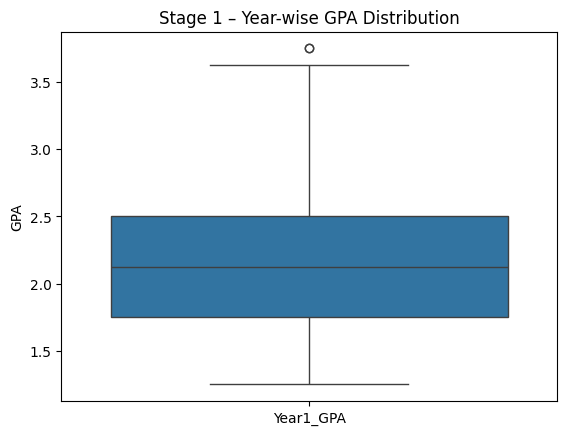

In [211]:
import seaborn as sns
import matplotlib.pyplot as plt

stage1 = df[df['Stage'] == 1]

sns.boxplot(data=stage1[['Year1_GPA']])
plt.title("Stage 1 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()



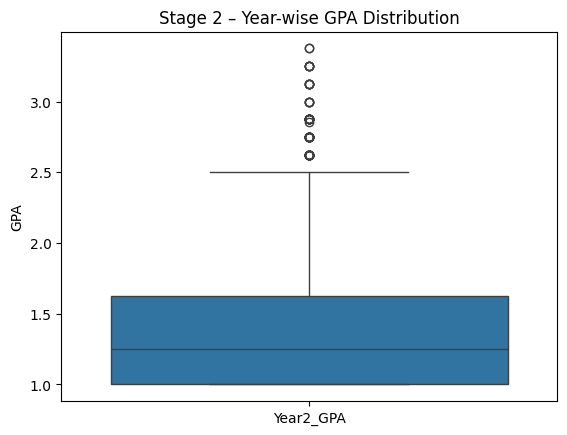

In [212]:
stage2 = df[df['Stage'] == 2]

sns.boxplot(data=stage2[['Year2_GPA']])
plt.title("Stage 2 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()


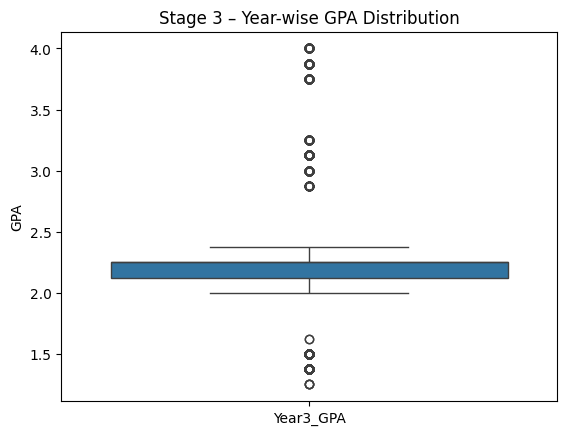

In [213]:
stage3 = df[df['Stage'] == 3]

sns.boxplot(data=stage3[['Year3_GPA']])
plt.title("Stage 3 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()


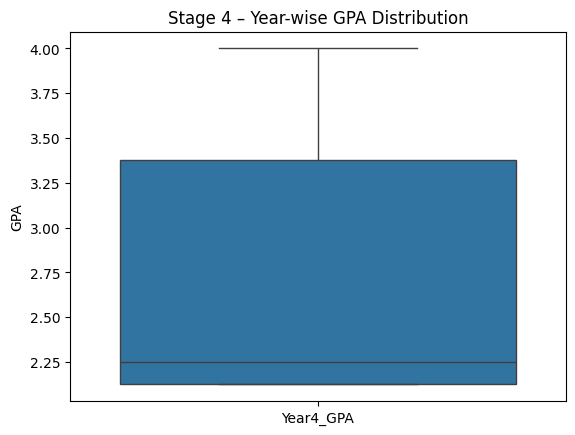

In [214]:
stage4 = df[df['Stage'] == 4]

sns.boxplot(data=stage4[['Year4_GPA']])
plt.title("Stage 4 – Year-wise GPA Distribution")
plt.ylabel("GPA")
plt.show()


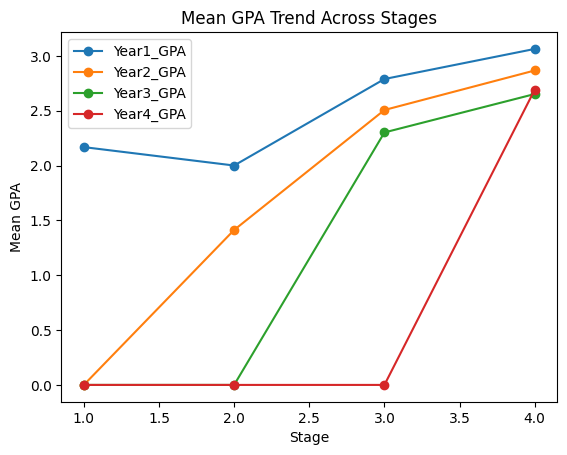

In [215]:
df.groupby('Stage')[['Year1_GPA','Year2_GPA','Year3_GPA','Year4_GPA']].mean().plot(marker='o')
plt.title("Mean GPA Trend Across Stages")
plt.ylabel("Mean GPA")
plt.show()


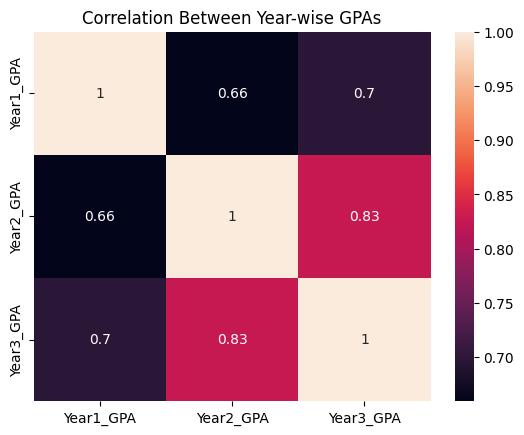

In [216]:
sns.heatmap(df[['Year1_GPA','Year2_GPA','Year3_GPA']].corr(), annot=True)
plt.title("Correlation Between Year-wise GPAs")
plt.show()


Year 3 Elective

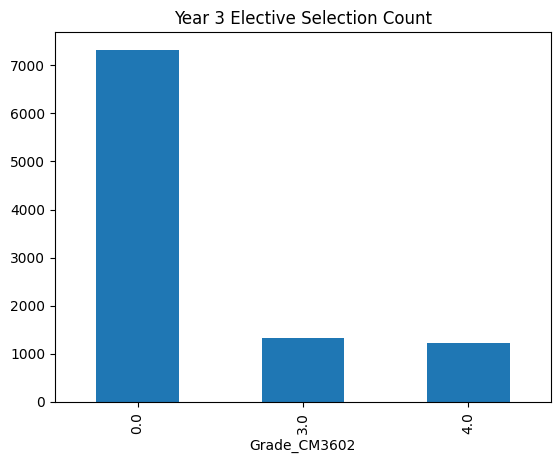

In [217]:

df['Grade_CM3602'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()


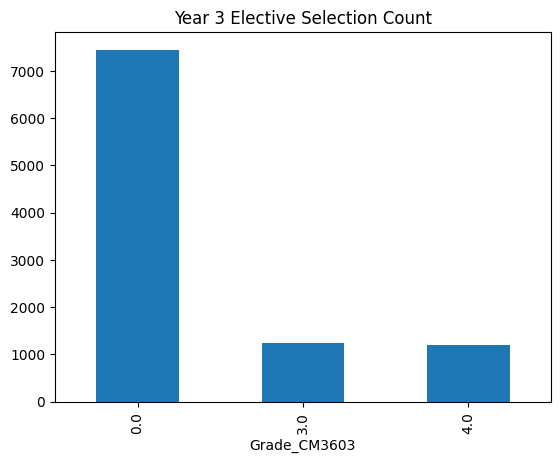

In [218]:
df['Grade_CM3603'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()

Year 4 Elective

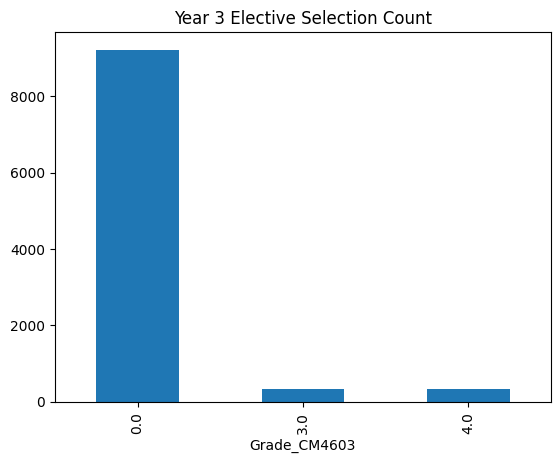

In [219]:
df['Grade_CM4603'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()

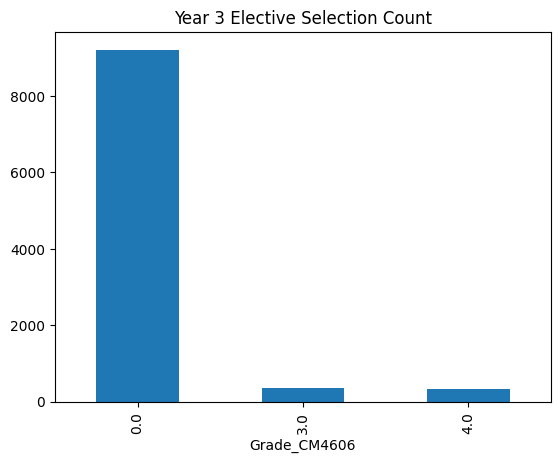

In [220]:
df['Grade_CM4606'].value_counts().plot(kind='bar')
plt.title("Year 3 Elective Selection Count")
plt.show()

CF based on Cosine Similarity Matrix

In [221]:
similarity_features = ['Year1_GPA', 'Year2_GPA']


In [222]:
similarity_features = ['Year1_GPA', 'Year2_GPA', 'Year3_GPA']


In [223]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[similarity_features])


In [224]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(scaled_features)


In [225]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df.index,
    columns=df.index
)


In [226]:
def recommend_year3(student_idx, df, similarity_df, elective_col, top_n=5):
    # Get similarities for the given student
    student_similarities = similarity_df.iloc[student_idx].sort_values(ascending=False)

    # Exclude the student itself and take top N similar students
    # Use index to get the actual student indices, excluding the first one (student_idx itself)
    top_n_similar_students_indices = student_similarities.index[1:top_n+1]

    # Filter the original DataFrame to get these similar students
    similar_students_df = df.loc[top_n_similar_students_indices]

    # Get grades for the specified elective from similar students who took it (grade > 0)
    valid_grades = similar_students_df[similar_students_df[elective_col] > 0][elective_col]

    # Calculate the mean grade. If no valid grades, return 0.0
    if not valid_grades.empty:
        predicted_grade = valid_grades.mean()
    else:
        predicted_grade = 0.0 # Or some default value if no neighbors took the course

    return predicted_grade

pred_cm3603 = recommend_year3(
    student_idx=2,
    df=df,
    similarity_df=similarity_df,
    elective_col='Grade_CM3603'
)

pred_cm3604 = recommend_year3(
    student_idx=2,
    df=df,
    similarity_df=similarity_df,
    elective_col='Grade_CM3602'
)

In [227]:
if pred_cm3603 > pred_cm3604:
    recommendation = "CM3603"
else:
    recommendation = "CM3602"

recommendation


'CM3602'

In [228]:
test_data = df[df['Grade_CM3603'] > 0].head(100)

# Assuming 'test_data' contains students who actually took CM3603
manual_predictions = []
actual_grades = test_data['Grade_CM3603'].tolist()

for idx in test_data.index:
    # We call your manual function
    pred = recommend_year3(idx, df, similarity_df, 'Grade_CM3603', top_n=5)
    manual_predictions.append(pred)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_manual = mean_absolute_error(actual_grades, manual_predictions)
rmse_manual = np.sqrt(mean_squared_error(actual_grades, manual_predictions))

print(f"Manual Matrix - MAE: {mae_manual:.4f}, RMSE: {rmse_manual:.4f}")

Manual Matrix - MAE: 0.3597, RMSE: 0.8169


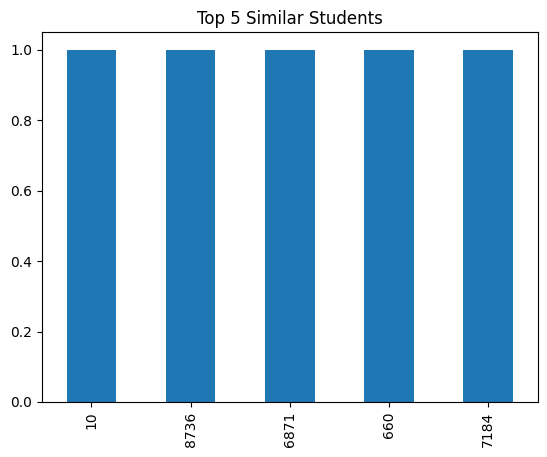

In [229]:
similarity_df.iloc[10].sort_values(ascending=False)[1:6].plot(kind='bar')
plt.title("Top 5 Similar Students")
plt.show()


CF based on KNN

In [230]:
X = df[['Stage','Year1_GPA', 'Year2_GPA']]
X_scaled = StandardScaler().fit_transform(X)


In [231]:
param_grid = {
    'n_neighbors': list(range(50, 501, 50))
}
print(param_grid)

{'n_neighbors': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]}


In [232]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,  # Using 5-fold cross-validation
    scoring='accuracy', # Using accuracy as the scoring metric
    n_jobs=-1 # Use all available cores
)

grid_search.fit(X_scaled, df['Stage'])

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Best parameters found:  {'n_neighbors': 50}
Best accuracy found:  0.9998989388580091


In [233]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get the best n_neighbors from GridSearchCV
best_n_neighbors = grid_search.best_params_['n_neighbors']
print(f"Using best n_neighbors: {best_n_neighbors}")

# Re-instantiate the NearestNeighbors model with the best n_neighbors
knn_optimized = NearestNeighbors(
    n_neighbors=best_n_neighbors,
    metric='cosine'
)
knn_optimized.fit(X_scaled)



Using best n_neighbors: 50


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [234]:
# Define the get_recommendation_numeric function to use the optimized knn model
def get_recommendation_numeric_optimized(student_index):
    distances, indices = knn_optimized.kneighbors(X_scaled[student_index].reshape(1, -1))
    neighbors = df.iloc[indices[0]]
    avg_grade = neighbors[neighbors['Grade_CM3603'] > 0]['Grade_CM3603'].mean()
    if pd.isna(avg_grade):
        return 0.0
    return avg_grade

# Re-evaluate the recommendation system for CM3603 with the optimized model
test_data = df[df['Grade_CM3603'] > 0].head(100)
actuals = test_data['Grade_CM3603']
predictions_optimized = [get_recommendation_numeric_optimized(idx) for idx in test_data.index]

mae_optimized = mean_absolute_error(actuals, predictions_optimized)
mse_optimized = mean_squared_error(actuals, predictions_optimized)
rmse_optimized = np.sqrt(mse_optimized)

print(f"\n--- Accuracy Results for CM3603 with optimized n_neighbors ({best_n_neighbors}) ---")
print(f"Mean Absolute Error (MAE): {mae_optimized:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_optimized:.4f}")


--- Accuracy Results for CM3603 with optimized n_neighbors (50) ---
Mean Absolute Error (MAE): 0.4772
Root Mean Squared Error (RMSE): 0.4900


MSE measures the average magnitude of the errors without considering their direction(+/-)
RMSE squares the errors before averaging them, then takes the square root of the result.

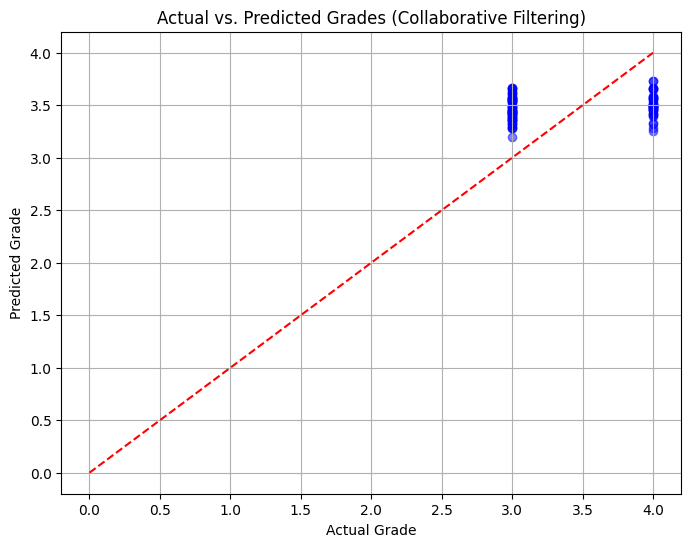

In [235]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions_optimized, alpha=0.5, color='blue')
plt.plot([0, 4], [0, 4], color='red', linestyle='--') # Diagonal line
plt.title('Actual vs. Predicted Grades (Collaborative Filtering)')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.grid(True)
plt.show()

In [236]:
def get_recommendation_for_student(student_index, df, X_scaled, knn_optimized):
    # 1. Find neighbors for the specific student index provided
    distances, indices = knn_optimized.kneighbors(X_scaled[student_index].reshape(1, -1))

    # 2. Get the data for those neighbors
    neighbors = df.iloc[indices[0]]

    # 3. Calculate average grades for the two electives among neighbors
    # We filter for > 0 to ensure we only average students who actually took the course
    avg_grade_3602 = neighbors[neighbors['Grade_CM3602'] > 0]['Grade_CM3602'].mean()
    avg_grade_3603 = neighbors[neighbors['Grade_CM3603'] > 0]['Grade_CM3603'].mean()

    # 4. Handle cases where no neighbors took a specific course (NaN check)
    avg_grade_3602 = 0 if pd.isna(avg_grade_3602) else avg_grade_3602
    avg_grade_3603 = 0 if pd.isna(avg_grade_3603) else avg_grade_3603

    # 5. Logic to decide recommendation
    if avg_grade_3602 > avg_grade_3603:
        return f"Student {student_index}: Recommend CM3602 (IoT) - Predicted Score: {avg_grade_3602:.2f}"
    else:
        return f"Student {student_index}: Recommend CM3603 (Edge AI) - Predicted Score: {avg_grade_3603:.2f}"

In [237]:
for i in range(10):
    print(get_recommendation_for_student(student_index=i, df=df, X_scaled=X_scaled, knn_optimized = knn_optimized))

Student 0: Recommend CM3603 (Edge AI) - Predicted Score: 0.00
Student 1: Recommend CM3603 (Edge AI) - Predicted Score: 3.48
Student 2: Recommend CM3603 (Edge AI) - Predicted Score: 3.60
Student 3: Recommend CM3603 (Edge AI) - Predicted Score: 0.00
Student 4: Recommend CM3603 (Edge AI) - Predicted Score: 0.00
Student 5: Recommend CM3603 (Edge AI) - Predicted Score: 0.00
Student 6: Recommend CM3602 (IoT) - Predicted Score: 3.56
Student 7: Recommend CM3603 (Edge AI) - Predicted Score: 0.00
Student 8: Recommend CM3603 (Edge AI) - Predicted Score: 0.00
Student 9: Recommend CM3603 (Edge AI) - Predicted Score: 0.00


In [238]:
import joblib

# 1. Save the KNN model
joblib.dump(knn_optimized, 'Stage3_elective_recommender_knn.pkl')

# 2. Save the Scaler (Crucial for consistent GPA scaling)
joblib.dump(scaler, 'gpa_scaler.pkl')

print("✅ Model and Scaler saved successfully!")


✅ Model and Scaler saved successfully!


Model for Year 4 Elective

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9892 entries, 0 to 9891
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Stage                                   9892 non-null   int64  
 1   hours_per_week                          9892 non-null   float64
 2   academic_stress                         9892 non-null   int64  
 3   struggle_with_managing                  9892 non-null   int64  
 4   start_assignments_closer_deadline       9892 non-null   int64  
 5   Skill_Programming                       9892 non-null   int64  
 6   Skill_Math                              9892 non-null   int64  
 7   Skill_Technical_Comm                    9892 non-null   int64  
 8   Skill_Web_Development                   9892 non-null   int64  
 9   Grade_CM1601                            9892 non-null   float64
 10  Grade_CM1602                            9892 non-null   floa

In [240]:
X4 = df[['Stage','Year1_GPA', 'Year2_GPA' , 'Year3_GPA']]
scaler4 = StandardScaler()
X4_scaled = scaler4.fit_transform(X4)

In [241]:
grid_search.fit(X4_scaled, df['Stage'])

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Best parameters found:  {'n_neighbors': 500}
Best accuracy found:  0.9938341463015863


In [242]:
best_n_neighbors = grid_search.best_params_['n_neighbors']
print(f"Using best n_neighbors: {best_n_neighbors}")

# Re-instantiate the NearestNeighbors model with the best n_neighbors
knn_optimized = NearestNeighbors(
    n_neighbors=best_n_neighbors,
    metric='cosine'
)
knn_optimized.fit(X4_scaled)

Using best n_neighbors: 500


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",500
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [243]:
# Define the get_recommendation_numeric function to use the optimized knn model
def get_recommendation_numeric_optimized(student_index):
    distances, indices = knn_optimized.kneighbors(X4_scaled[student_index].reshape(1, -1))
    neighbors = df.iloc[indices[0]]
    avg_grade = neighbors[neighbors['Grade_CM4603'] > 0]['Grade_CM4603'].mean()
    if pd.isna(avg_grade):
        return 0.0
    return avg_grade

# Re-evaluate the recommendation system for CM4603 with the optimized model
test_data = df[df['Grade_CM4603'] > 0].head(100)
actuals = test_data['Grade_CM4603']
predictions_optimized = [get_recommendation_numeric_optimized(idx) for idx in test_data.index]

mae_optimized = mean_absolute_error(actuals, predictions_optimized)
mse_optimized = mean_squared_error(actuals, predictions_optimized)
rmse_optimized = np.sqrt(mse_optimized)

print(f"\n--- Accuracy Results for CM4603 with optimized n_neighbors ({best_n_neighbors}) ---")
print(f"Mean Absolute Error (MAE): {mae_optimized:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_optimized:.4f}")


--- Accuracy Results for CM4603 with optimized n_neighbors (500) ---
Mean Absolute Error (MAE): 0.4969
Root Mean Squared Error (RMSE): 0.4986


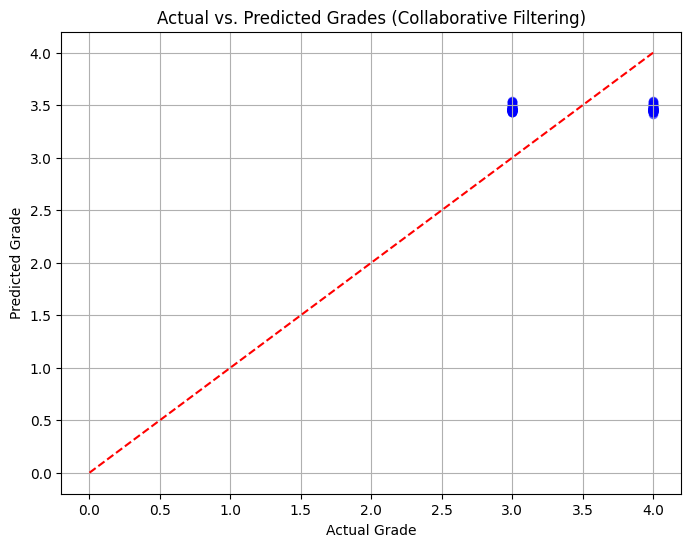

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions_optimized, alpha=0.5, color='blue')
plt.plot([0, 4], [0, 4], color='red', linestyle='--') # Diagonal line
plt.title('Actual vs. Predicted Grades (Collaborative Filtering)')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.grid(True)
plt.show()

In [245]:
def get_recommendation_for_student(student_index, df, X4_scaled, knn_optimized):
    # 1. Find neighbors for the specific student index provided
    distances, indices = knn_optimized.kneighbors(X4_scaled[student_index].reshape(1, -1))

    # 2. Get the data for those neighbors
    neighbors = df.iloc[indices[0]]

    # 3. Calculate average grades for the two electives among neighbors
    # We filter for > 0 to ensure we only average students who actually took the course
    avg_grade_4606 = neighbors[neighbors['Grade_CM4606'] > 0]['Grade_CM4606'].mean()
    avg_grade_4603 = neighbors[neighbors['Grade_CM4603'] > 0]['Grade_CM4603'].mean()

    # 4. Handle cases where no neighbors took a specific course (NaN check)
    avg_grade_4606 = 0 if pd.isna(avg_grade_4606) else avg_grade_4606
    avg_grade_4603 = 0 if pd.isna(avg_grade_4603) else avg_grade_4603

    # 5. Logic to decide recommendation
    if avg_grade_4606 > avg_grade_4603:
        return f"Student {student_index}: Recommend CM4606 (Advanced IoT) - Predicted Score: {avg_grade_4606:.2f}"
    else:
        return f"Student {student_index}: Recommend CM4603 (Edge AI) - Predicted Score: {avg_grade_4603:.2f}"
    


In [246]:
for i in range(10):
        print(get_recommendation_for_student(student_index=i, df=df, X4_scaled=X4_scaled, knn_optimized=knn_optimized))

Student 0: Recommend CM4603 (Edge AI) - Predicted Score: 0.00
Student 1: Recommend CM4603 (Edge AI) - Predicted Score: 3.45
Student 2: Recommend CM4603 (Edge AI) - Predicted Score: 3.44
Student 3: Recommend CM4603 (Edge AI) - Predicted Score: 0.00
Student 4: Recommend CM4603 (Edge AI) - Predicted Score: 0.00
Student 5: Recommend CM4603 (Edge AI) - Predicted Score: 0.00
Student 6: Recommend CM4606 (Advanced IoT) - Predicted Score: 3.55
Student 7: Recommend CM4603 (Edge AI) - Predicted Score: 0.00
Student 8: Recommend CM4603 (Edge AI) - Predicted Score: 0.00
Student 9: Recommend CM4603 (Edge AI) - Predicted Score: 0.00


In [247]:
# 1. Save the KNN model
joblib.dump(knn_optimized, 'Stage4_elective_recommender_knn.pkl')

# 2. Save the Scaler (Crucial for consistent GPA scaling)
joblib.dump(scaler4, 'gpa_scaler4.pkl')

print("✅ Model and Scaler saved successfully!")

✅ Model and Scaler saved successfully!
